# Modelo de Regressão Linear

Este notebook demonstra, em etapas, como criar um conjunto simples de dados, ajustar uma regressão linear, fazer uma previsão, avaliar o ajuste com R² e comparar o comportamento do modelo quando os dados têm ruído.


## 1. Bibliotecas

As bibliotecas importadas cobrem três partes do fluxo: criação/manipulação de dados com NumPy, visualização com Matplotlib e treinamento/avaliação do modelo com scikit-learn. O `pandas` fica disponível para cenários em que os dados venham de tabelas, embora este exemplo use arrays criados manualmente.


In [1]:
# Importa as bibliotecas usadas no notebook: dados, gráficos, modelo e métrica.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## 2. Dados de exemplo

Aqui são definidos os pares entrada-saída: `X` representa o tempo de operação e `y` representa o consumo de energia. O `reshape(-1, 1)` transforma `X` em uma matriz com uma coluna, formato esperado pelo `LinearRegression` do scikit-learn.


In [ ]:
# Define os dados de treino do exemplo simples.
# tempo de operação (entrada)
X = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1) 
# O -1 significa: calcule automaticamente quantas linhas são necessárias. 
# O 1 significa: quero exatamente 1 coluna.
# Sendo assim X é um vetor coluna, ou seja, um array bidimensional.

# consumo de energia (saída)
y = np.array([10, 20, 30, 40, 55, 65])
# Observe que y é um vetor linha, ou seja, um array unidimensional.

## 3. Visualização inicial

O gráfico de dispersão ajuda a verificar visualmente se existe uma tendência aproximadamente linear entre tempo e consumo antes de treinar o modelo.


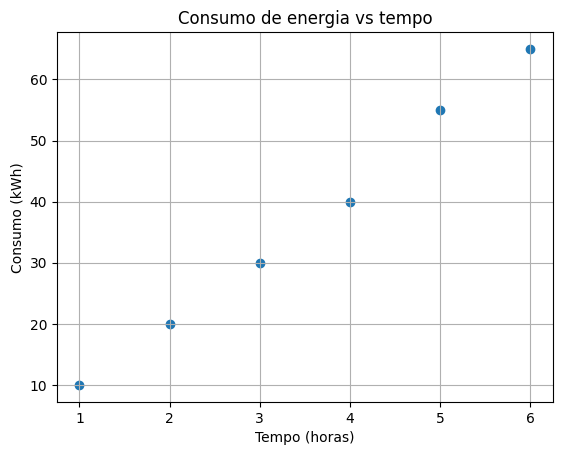

In [3]:
# Plota os pontos reais para observar a relação entre entrada e saída.
plt.scatter(X, y)
plt.xlabel("Tempo (horas)")
plt.ylabel("Consumo (kWh)")
plt.title("Consumo de energia vs tempo")
plt.grid()
plt.show()

## 4. Treinamento do modelo

A regressão linear procura a reta que melhor aproxima os pontos observados. Depois do `fit`, o objeto `model` passa a armazenar os parâmetros aprendidos: coeficiente angular e intercepto.


In [6]:
# Cria e treina o modelo de regressão linear com os dados definidos acima.
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 5. Previsão

Com o modelo treinado, é possível estimar o consumo para um novo tempo de operação. O novo valor também é passado como matriz bidimensional para manter o formato esperado pelo scikit-learn.


In [ ]:
# Usa o modelo treinado para prever o consumo em um novo tempo de operação.
novo_tempo = np.array([[7]])
previsao = model.predict(novo_tempo)

print(f"Consumo previsto: {previsao[0]:.2f} kWh")

Consumo previsto: 75.67 kWh


## 6. Reta aprendida

Nesta etapa, o modelo gera previsões para os próprios valores de treino. Isso permite desenhar a reta aprendida por cima dos dados reais e comparar visualmente o ajuste.


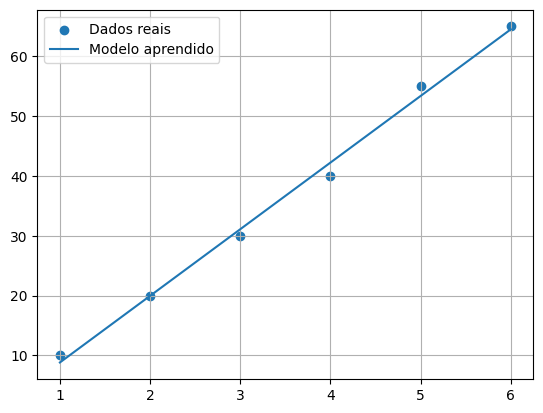

In [ ]:
# Calcula as previsões nos dados de treino e compara a reta com os pontos reais.
y_pred = model.predict(X)

plt.scatter(X, y, label="Dados reais")
plt.plot(X, y_pred, label="Modelo aprendido")
plt.legend()
plt.grid()
plt.show()

## 7. Parâmetros da reta

O coeficiente indica quanto o consumo previsto aumenta, em média, para cada hora adicional. O intercepto é o valor estimado quando o tempo é zero, dentro da extrapolação matemática da reta.


In [ ]:
# Exibe os parâmetros aprendidos pela regressão linear.
print("Coeficiente:", model.coef_[0])
print("Intercepto:", model.intercept_)

Coeficiente: 11.142857142857144
Intercepto: -2.333333333333343


## 8. Qualidade do ajuste

O R² mede a proporção da variação de `y` explicada pelo modelo. Valores mais próximos de 1 indicam melhor ajuste aos dados usados na avaliação; em bases pequenas, ele deve ser interpretado com cuidado.


In [ ]:
# Avalia o ajuste do modelo usando o coeficiente de determinação R².
r2 = r2_score(y, y_pred)
print("R²:", r2)

R²: 0.9952017448200654


## 9. Dados com ruído

Para aproximar o exemplo de um cenário real, este bloco cria uma tendência linear com variação aleatória. A semente fixa (`np.random.seed(42)`) torna o resultado reprodutível a cada execução.


In [ ]:
# Gera um conjunto sintético maior, com tendência linear e ruído aleatório.
np.random.seed(42)

X_real = np.linspace(30, 130, 50).reshape(-1, 1)
ruido = np.random.normal(0, 20, size=50)

y_real = 3 * X_real.flatten() + 50 + ruido

## 10. Modelo nos dados com ruído

O mesmo algoritmo é aplicado ao conjunto sintético com ruído. A ideia é mostrar que a regressão linear não precisa passar exatamente por todos os pontos: ela busca a melhor tendência média.


In [ ]:
# Treina uma nova regressão linear e calcula suas previsões para os dados ruidosos.
model_real = LinearRegression()
model_real.fit(X_real, y_real)

y_pred_real = model_real.predict(X_real)

## 11. Visualização do caso mais realista

O último gráfico mostra os pontos com dispersão e a reta estimada pelo modelo. Essa comparação reforça a diferença entre observar dados reais, que variam, e ajustar uma tendência linear.


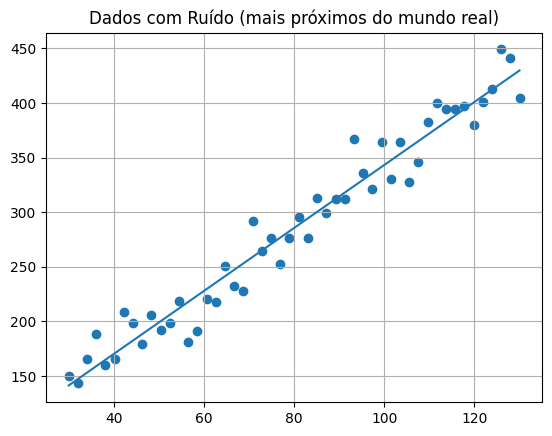

In [ ]:
# Plota os dados com ruído junto com a reta ajustada pelo segundo modelo.
plt.scatter(X_real, y_real)
plt.plot(X_real, y_pred_real)
plt.title("Dados com Ruído (mais próximos do mundo real)")
plt.grid()
plt.show()